# Lab 01 - NumPY, Vectors, Matrices

In [17]:
import numpy as np

## Exercise 1 - Vectors

In [18]:
# Initialize two arrays of length 6
x = np.array([1, 2, 3, 4, 5, 6])
y = np.array([7, 8, 9, 10, 11, 12])

# Extract the first 3 elements of x
x_first_elems = x[:3]

# Extract the last 3 elements of y
y_last_elems = y[3:]

# Concatenate x_first_elems and y_last_elems
z = np.concatenate((x_first_elems, y_last_elems))

# Stack x, y and z
m = np.stack((x, y, z))

# Print the number of dimensions, the size and the shape of m

print(f"{m}\n {m.ndim} - {m.size} - {m.shape}")

[[ 1  2  3  4  5  6]
 [ 7  8  9 10 11 12]
 [ 1  2  3 10 11 12]]
 2 - 18 - (3, 6)


In [19]:
# Given an array, print all the elements with a value between 3 and 7 (included), WITHOUT using loops
a = np.array([1, 2, 3, 5, 7, 3, 4, 12, 2, 5, 6, 8, 9, 3, 3, 1, 1, 2, 9, 3, 7, 8, 10])

guard = a[(a > 2) & (a < 8)]

guard


array([3, 5, 7, 3, 4, 5, 6, 3, 3, 3, 7])

## Exercise 2 - Matrices

In [20]:
# Create a 3x4 matrix of random integers between 1 and 10
matrix = np.random.randint(1, 11, size=(3, 4))

matrix

array([[ 8,  2, 10,  1],
       [ 1,  4,  6,  7],
       [ 5,  6,  3, 10]])

In [21]:
# Create a 3x4 matrix of ones
ones_matrix = np.ones((3,4))

ones_matrix

array([[1., 1., 1., 1.],
       [1., 1., 1., 1.],
       [1., 1., 1., 1.]])

In [22]:
# Sum the two matrices and visualize the resulting matrix
sum_matrix = matrix + ones_matrix

sum_matrix

array([[ 9.,  3., 11.,  2.],
       [ 2.,  5.,  7.,  8.],
       [ 6.,  7.,  4., 11.]])

In [23]:
# Sum one to each cell of the resulting matrix without using loops
sum_matrix += np.ones((3,4))

sum_matrix

array([[10.,  4., 12.,  3.],
       [ 3.,  6.,  8.,  9.],
       [ 7.,  8.,  5., 12.]])

In [24]:
# Compute the sum of all the elements of the matrix (no loops)
s = np.sum(sum_matrix)

# Compute the minimum and the maximum elements of the matrix (no loops)
min_el = np.min(sum_matrix)
max_el = np.max(sum_matrix)


# Compute the sum of each row of the matrix
row_sums = np.sum(sum_matrix, axis=1)

# Compute the minimum of each column of the matrix
col_mins = np.min(sum_matrix, axis=0)

print(f"sum:{s}, min:{min_el}, max:{max_el}, row sums:{row_sums}, column mins:{col_mins}")

sum:87.0, min:3.0, max:12.0, row sums:[29. 26. 32.], column mins:[3. 4. 5. 3.]


In [25]:
# Collapse the matrix in a 1d-array
flattened_matrix = sum_matrix.flatten()

print(flattened_matrix)

# Reshape the matrix to have a shape equal to (6, 2)
reshaped_matrix = sum_matrix.reshape(6,2)

reshaped_matrix

[10.  4. 12.  3.  3.  6.  8.  9.  7.  8.  5. 12.]


array([[10.,  4.],
       [12.,  3.],
       [ 3.,  6.],
       [ 8.,  9.],
       [ 7.,  8.],
       [ 5., 12.]])

In [26]:
# Generate an array of 6 random integers
random_array = np.random.randint(1, 11, size=6)

random_array

array([ 6,  5,  1, 10,  5,  4])

In [27]:
# Add a new axis using np.newaxis
random_array_2d = random_array[np.newaxis, :]

random_array_2d

array([[ 6,  5,  1, 10,  5,  4]])

## Exercise 3 - Euclidean Distance

The Euclidean distance between two points is obtained by computing the length of the straight line connecting those points.
Mathematically, it is defined as:
        $$d(p, q) = \sqrt{(q_1 - p_1)^2 + (q_2 - p_2)^2 + \dots + (q_n - p_n)^2}$$
for any pair of n-dimensional points

In [28]:
# Define first matrix: 2 points in 2D space
A = np.array([[0, 0], [1, 1]])

# Define second matrix: 3 points in 3D space
B = np.array([[1, 0],
              [0, 1],
              [3, 3]])

In [29]:
# Compute the distance matrix, containing the Euclidean distance between any pair of points one can obtain combining A and B
# Loops are allowed

matrix = np.zeros((A.shape[0], B.shape[0]))

for i in range(A.shape[0]):
    for j in range(B.shape[0]):
        matrix[i, j] = np.sqrt(np.sum(np.square(A[i] - B[j])))  

matrix

array([[1.        , 1.        , 4.24264069],
       [1.        , 1.        , 2.82842712]])

In [30]:
# Compute the distance matrix without using loops

# Sum of squares for each row in A
A_sq = np.sum(np.square(A), axis=1).reshape(-1, 1)

# Sum of squares for each row in B
B_sq = np.sum(np.square(B), axis=1).reshape(-1, 1)

# Perform matrix multiplication
AB = np.dot(A, B.T)

# Apply the (A^2 + B^2 - 2AB) formula
dists_sq = A_sq + B_sq.T - 2 * AB

# Compute the square root of the distances
dists = np.sqrt(dists_sq)

# Print distance matrix
print("Distance Matrix:\n", dists)

Distance Matrix:
 [[1.         1.         4.24264069]
 [1.         1.         2.82842712]]


## Exercise 4 - Matplotlib

In [31]:
import matplotlib.pyplot as plt
from PIL import Image

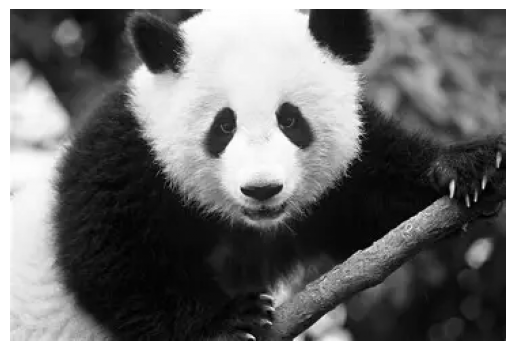

In [32]:
# Load the panda image in greyscale using PIL
I = Image.open('panda.png').convert('L')

# Display the image
plt.imshow(I, cmap='gray')
plt.axis('off') # Hide axes for cleaner image display
plt.show()

In [33]:
# Extract the array representing the image
I_array = np.array(I)

# Extract the max and min values from the image
min_val = np.min(I_array)
max_val = np.max(I_array)

print("Minimum value:", min_val)
print("Maximum value:", max_val)

Minimum value: 0
Maximum value: 255


In [34]:
# Print the coordinates of pixels containing max and min values
guard = np.where((I_array == min_val) | (I_array == max_val))
coords = list(zip(guard[0], guard[1]))

print("Coordinates of pixels with max and min values:")
print(coords)

Coordinates of pixels with max and min values:
[(np.int64(3), np.int64(210)), (np.int64(10), np.int64(131)), (np.int64(93), np.int64(258)), (np.int64(93), np.int64(263)), (np.int64(94), np.int64(166)), (np.int64(94), np.int64(201)), (np.int64(95), np.int64(166)), (np.int64(95), np.int64(200)), (np.int64(96), np.int64(166)), (np.int64(97), np.int64(163)), (np.int64(97), np.int64(204)), (np.int64(98), np.int64(162)), (np.int64(99), np.int64(189)), (np.int64(109), np.int64(356)), (np.int64(116), np.int64(362)), (np.int64(116), np.int64(363)), (np.int64(118), np.int64(250)), (np.int64(120), np.int64(335)), (np.int64(126), np.int64(346)), (np.int64(127), np.int64(346)), (np.int64(128), np.int64(346)), (np.int64(130), np.int64(350)), (np.int64(131), np.int64(328)), (np.int64(132), np.int64(328)), (np.int64(132), np.int64(350)), (np.int64(132), np.int64(351)), (np.int64(133), np.int64(350)), (np.int64(133), np.int64(351)), (np.int64(134), np.int64(347)), (np.int64(135), np.int64(347)), (np.in

In [35]:
# Perform a "filter inversion" of the image: create a copy of the original image inverting the values of the pixels
I_inverted = 255 - I_array

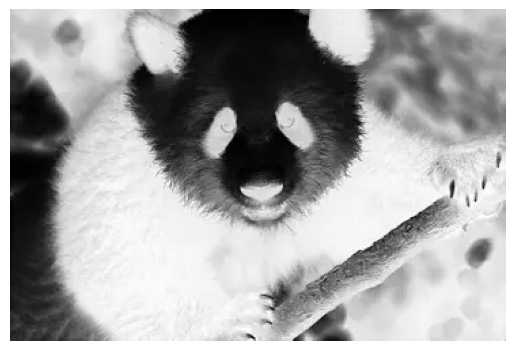

In [36]:
# Display the inverted image
plt.imshow(I_inverted, cmap='gray')
plt.axis('off') # Hide axes for cleaner image display
plt.show()